In [2]:
!pip install kagglehub


In [3]:
import kagglehub


path = kagglehub.dataset_download("emmarex/plantdisease")

print("✅ Path to dataset files:", path)

100%|██████████| 658M/658M [00:02<00:00, 252MB/s]  


Extracting files...
✅ Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1


In [19]:
import os

root = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1"

file_count = 0
for dirname, _, filenames in os.walk(root):
    for filename in filenames:
        if file_count < 30:  # only print first 30 file paths
            print(os.path.join(dirname, filename))
        file_count += 1

print(f"\nTotal files found: {file_count}")


/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/plantvillage/PlantVillage/Tomato_healthy/f7069452-9405-45a6-bfb3-f21ea42b9b02___RS_HL 9966.JPG
/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/plantvillage/PlantVillage/Tomato_healthy/b840b04b-5909-4e35-beb8-7f53098975b1___RS_HL 0324.JPG
/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/plantvillage/PlantVillage/Tomato_healthy/6fc5b781-6757-459f-af96-09a67dbcb2bc___RS_HL 0607.JPG
/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/plantvillage/PlantVillage/Tomato_healthy/63568703-0cfc-4d23-a5e1-e3393df2d2fc___RS_HL 0246.JPG
/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/plantvillage/PlantVillage/Tomato_healthy/caa60224-1c60-455e-8b7c-e73626af84c1___GH_HL Leaf 214.JPG
/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdiseas

In [6]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras pillow opencv-python tqdm kagglehub


INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 101.0 MB/s  0:00:030:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 114.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 189.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 193.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 138.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 214.6 MB/s  0:00:00
  Attempting uninstall: protobuf90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/18 [termcolor]
    Found existing installation: protobuf 4.23.4━━━━━━━━━━━━━━  4/18 [termcolor]
    Uninstalling protobuf-4.23.4:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/18 [termcolor]
      Successfully uninstalled protobuf-4.23.4━

In [10]:
from collections import Counter
from sklearn.metrics import roc_auc_score, roc_curve, auc
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os
import os, numpy as np, tensorflow as tf
import tensorflow as tf


In [20]:
import os, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ----------------- User params -----------------
dataset_path = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/plantvillage/PlantVillage/"  # adjust if different
img_height = 128
img_width = 128
channels = 3
batch_size = 32
latent_dim = 64           # 64 is a good start; reduce to 32 for speed if needed
beta = 1.0                # KL weight
epochs = 30               # reduce for quick tests
learning_rate = 1e-5      # low LR to avoid instabilities
USE_PERCEPTUAL = False    # set True after training is stable (slower when True)
# ------------------------------------------------

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

# ---------- Dataset ----------
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

def preprocess_image(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)  # [0,1]
    return image, image  # model target = input (autoencoder)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 20638 files belonging to 15 classes.


I0000 00:00:1762183016.507875    6969 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [21]:
# quick data sanity check
def check_data(ds, n=5):
    for i, (x, _) in enumerate(ds.take(n)):
        if tf.reduce_any(tf.math.is_nan(x)) or tf.reduce_any(tf.math.is_inf(x)):
            print("Bad data at batch", i)
            return False
    print("No NaN/Inf detected in first", n, "batches")
    return True

_ = check_data(train_ds, n=10)

# ---------- Perceptual extractor (lightweight) ----------
# Use MobileNetV2 features when USE_PERCEPTUAL True (faster than VGG)
if USE_PERCEPTUAL:
    from tensorflow.keras.applications import MobileNetV2
    mobile = MobileNetV2(include_top=False, weights='imagenet', input_shape=(img_height, img_width, 3))
    # pick an intermediate layer for perceptual features
    mobile_feat_extractor = keras.Model(inputs=mobile.input, outputs=mobile.get_layer('block_6_expand').output)
    mobile_feat_extractor.trainable = False

    def perceptual_preprocess(x):
        x = x * 255.0
        return tf.keras.applications.mobilenet_v2.preprocess_input(x)
else:
    mobile_feat_extractor = None
    perceptual_preprocess = None

2025-11-03 15:17:34.875352: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 501 of 1000


No NaN/Inf detected in first 10 batches


2025-11-03 15:17:38.110693: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-11-03 15:17:38.161251: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [22]:
# ---------- Model builders ----------
def make_encoder(latent_dim):
    inputs = layers.Input(shape=(img_height, img_width, channels))
    x = layers.Conv2D(64, 3, strides=1, padding='same', activation='relu')(inputs)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, 3, strides=1, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, 3, strides=1, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(512, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_logvar = layers.Dense(latent_dim, name='z_logvar')(x)
    return keras.Model(inputs, [z_mean, z_logvar], name='encoder')

In [23]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_logvar = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps


In [24]:
def make_decoder(latent_dim):
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(8*8*512, activation='relu')(latent_inputs)
    x = layers.Reshape((8, 8, 512))(x)

    x = layers.UpSampling2D()(x)  # 16x16
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D()(x)  # 32x32
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D()(x)  # 64x64
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D()(x)  # 128x128
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(channels, 3, padding='same', activation='sigmoid')(x)
    return keras.Model(latent_inputs, outputs, name='decoder')

# build models
encoder = make_encoder(latent_dim)
decoder = make_decoder(latent_dim)
sampling = Sampling()

In [25]:
# ---------- VAE w/ robust loss (safe numeric handling) ----------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, feat_extractor=None, beta=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.feat_extractor = feat_extractor
        self.beta = beta
        self.sampling = Sampling() # Add sampling layer

        self.total_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_tracker = keras.metrics.Mean(name="recon_loss")
        self.perc_tracker = keras.metrics.Mean(name="perc_loss")
        self.ssim_tracker = keras.metrics.Mean(name="ssim")
        self.kl_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_tracker, self.recon_tracker, self.perc_tracker, self.ssim_tracker, self.kl_tracker]

    def call(self, inputs):
        z_mean, z_logvar = self.encoder(inputs)
        z = self.sampling([z_mean, z_logvar])
        reconstruction = self.decoder(z)
        return reconstruction # Return the reconstruction

    def compute_kl(self, z_mean, z_logvar):
        # clip logvar to prevent exp overflow
        clipped_logvar = tf.clip_by_value(z_logvar, -30.0, 20.0)
        sigma_sq = tf.exp(clipped_logvar)
        kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + clipped_logvar - tf.square(z_mean) - sigma_sq, axis=1))
        return kl, clipped_logvar

    def train_step(self, data):
        x, _ = data
        # ensure float32 to avoid numeric issues
        x = tf.cast(x, tf.float32)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x, training=True)
            # clip early for numeric stability
            zipped_logvar = tf.clip_by_value(z_logvar, -30.0, 20.0)
            z = zipped_logvar  # placeholder to avoid reuse name (will compute proper sampling below)
            # re-sample correctly
            eps = tf.random.normal(shape=tf.shape(z_mean))
            z = z_mean + tf.exp(0.5 * zipped_logvar) * eps

            x_recon = self.decoder(z, training=True)

            # L1 reconstruction
            l1_loss = tf.reduce_mean(tf.reduce_sum(tf.abs(x - x_recon), axis=[1,2,3]))

            # SSIM similarity
            ssim_val = tf.reduce_mean(tf.image.ssim(x, x_recon, max_val=1.0))
            ssim_loss = 1.0 - ssim_val

            # Perceptual (optional + smaller extractor)
            if self.feat_extractor is not None and USE_PERCEPTUAL:
                # clip inputs and preprocess for the extractor
                x_p = tf.clip_by_value(x, 0.0, 1.0)
                xr_p = tf.clip_by_value(x_recon, 0.0, 1.0)
                x_p = perceptual_preprocess(x_p)
                xr_p = perceptual_preprocess(xr_p)
                f_x = self.feat_extractor(x_p)
                f_xr = self.feat_extractor(xr_p)
                perc_loss = tf.reduce_mean(tf.reduce_sum(tf.abs(f_x - f_xr), axis=[1,2,3]))
            else:
                perc_loss = 0.0

            # KL (use safe compute)
            kl_loss, _ = self.compute_kl(z_mean, z_logvar)

            recon_loss = 1.0 * l1_loss + 0.8 * perc_loss + 0.6 * ssim_loss
            total_loss = recon_loss + self.beta * kl_loss

            # guard: replace NaN/Inf with large scalar so gradients remain finite
            total_loss = tf.where(tf.math.is_finite(total_loss), total_loss, tf.constant(1e6, dtype=total_loss.dtype))


        grads = tape.gradient(total_loss, self.trainable_weights)
        # clip gradients by norm
        grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_tracker.update_state(total_loss)
        self.recon_tracker.update_state(recon_loss)
        self.perc_tracker.update_state(perc_loss if isinstance(perc_loss, tf.Tensor) else 0.0)
        self.ssim_tracker.update_state(ssim_val)
        self.kl_tracker.update_state(kl_loss)

        return {
            "loss": self.total_tracker.result(),
            "recon_loss": self.recon_tracker.result(),
            "perceptual_loss": self.perc_tracker.result(),
            "ssim": self.ssim_tracker.result(),
            "kl_loss": self.kl_tracker.result(),
        }

    def test_step(self, data):
        x, _ = data
        x = tf.cast(x, tf.float32)
        z_mean, z_logvar = self.encoder(x, training=False)
        z = z_mean  # deterministic
        x_recon = self.decoder(z, training=False)

        l1_loss = tf.reduce_mean(tf.reduce_sum(tf.abs(x - x_recon), axis=[1,2,3]))
        ssim_val = tf.reduce_mean(tf.image.ssim(x, x_recon, max_val=1.0))
        ssim_loss = 1.0 - ssim_val


        if self.feat_extractor is not None and USE_PERCEPTUAL:
            x_p = tf.clip_by_value(x, 0.0, 1.0)
            xr_p = tf.clip_by_value(x_recon, 0.0, 1.0)
            x_p = perceptual_preprocess(x_p)
            xr_p = perceptual_preprocess(xr_p)
            f_x = self.feat_extractor(x_p)
            f_xr = self.feat_extractor(xr_p)
            perc_loss = tf.reduce_mean(tf.reduce_sum(tf.abs(f_x - f_xr), axis=[1,2,3]))
        else:
            perc_loss = 0.0

        kl_loss, _ = self.compute_kl(z_mean, z_logvar)
        recon_loss = 1.0 * l1_loss + 0.8 * perc_loss + 0.6 * ssim_loss
        total_loss = recon_loss + self.beta * kl_loss

        self.total_tracker.update_state(total_loss)
        self.recon_tracker.update_state(recon_loss)
        self.perc_tracker.update_state(perc_loss if isinstance(perc_loss, tf.Tensor) else 0.0)
        self.ssim_tracker.update_state(ssim_val)
        self.kl_tracker.update_state(kl_loss)

        return {
            "loss": self.total_tracker.result(),
            "recon_loss": self.recon_tracker.result(),
            "perceptual_loss": self.perc_tracker.result(),
            "ssim": self.ssim_tracker.result(),
            "kl_loss": self.kl_tracker.result(),
        }

In [26]:
# instantiate VAE
vae = VAE(encoder, decoder, feat_extractor=mobile_feat_extractor, beta=beta)

In [27]:
# compile with small LR and clipnorm to further protect against explosions
opt = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
vae.compile(optimizer=opt)

In [28]:
# callbacks
checkpoint_dir = "./vae_improved_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "vae_best.weights.h5"),
    save_weights_only=True,
    save_best_only=True,
    monitor="loss",
    verbose=1,
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="loss", factor=0.5, patience=6, min_lr=1e-7, verbose=1)

In [29]:
# Explicitly build the VAE model by passing a sample batch of data
for x, _ in train_ds.take(1):
    vae(x) # Call the model on a sample batch to build it
    print("✅ VAE model built.")
    break

2025-11-03 15:19:15.133882: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


✅ VAE model built.


In [31]:
history = vae.fit(train_ds, epochs=epochs, callbacks=[checkpoint_cb, reduce_lr])

Epoch 1/30
433/645 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - kl_loss: 188.7679 - loss: 6656.0869 - perceptual_loss: 0.0000e+00 - recon_loss: 6467.3195 - ssim: 0.1570

2025-11-03 15:22:50.458765: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-11-03 15:22:50.459014: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-11-03 15:22:50.459404: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-11-03 15:22:50.459594: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2025-11-03 15:22:52.849493: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[30,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[30,3,128,128]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_con

645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - kl_loss: 180.5484 - loss: 6356.3409 - perceptual_loss: 0.0000e+00 - recon_loss: 6175.7930 - ssim: 0.1711
Epoch 1: loss improved from None to 5601.43506, saving model to ./vae_improved_checkpoints/vae_best.weights.h5
645/645 ━━━━━━━━━━━━━━━━━━━━ 149s 231ms/step - kl_loss: 160.1466 - loss: 5601.4351 - perceptual_loss: 0.0000e+00 - recon_loss: 5441.2886 - ssim: 0.2067 - learning_rate: 1.0000e-05
Epoch 2/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - kl_loss: 140.9745 - loss: 4727.2819 - perceptual_loss: 0.0000e+00 - recon_loss: 4586.3079 - ssim: 0.2523
Epoch 2: loss improved from 5601.43506 to 4621.63525, saving model to ./vae_improved_checkpoints/vae_best.weights.h5
645/645 ━━━━━━━━━━━━━━━━━━━━ 117s 182ms/step - kl_loss: 140.5332 - loss: 4621.6353 - perceptual_loss: 0.0000e+00 - recon_loss: 4481.1079 - ssim: 0.2576 - learning_rate: 1.0000e-05
Epoch 3/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - kl_loss: 139.8716 - loss: 4374.2148 - percept

In [32]:
# ---------- Save final weights ----------
vae.save_weights(os.path.join(checkpoint_dir, "vae_final.weights.h5"))

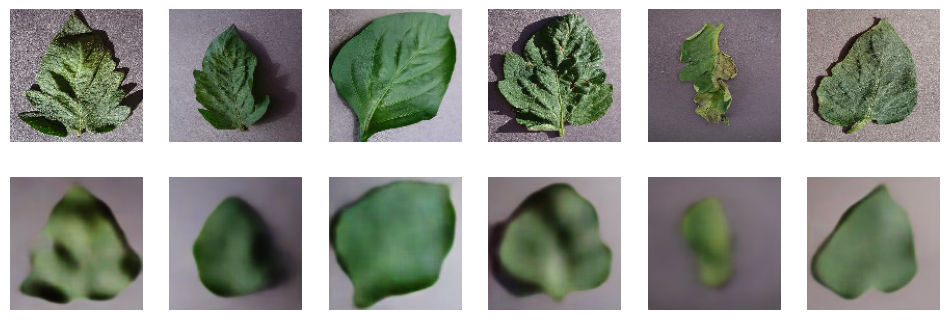

In [35]:

# ---------- Quick visualization ----------
def show_pair(originals, reconstructions, n=6):
    originals = originals[:n].numpy()
    reconstructions = reconstructions[:n].numpy()
    plt.figure(figsize=(12,4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(originals[i])
        plt.axis('off')
        plt.subplot(2, n, n+i+1)
        plt.imshow(reconstructions[i])
        plt.axis('off')
    plt.show()

for batch in train_ds.take(1):
    x_sample, _ = batch
    break

z_mean, z_logvar = encoder(x_sample, training=False)
x_recon = decoder(z_mean, training=False)
show_pair(x_sample, x_recon, n=6)


In [36]:
# ---------- ANOMALY DETECTION PIPELINE (run after your training/saving code) ----------
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras

# ------------- Settings (tweak as needed) -------------
score_batch_size = 32
percentile_threshold = 95   # threshold = percentile of scores (when labels unavailable)
top_k_examples = 6
out_csv = "anomaly_scores.csv"
# ------------------------------------------------------

# 1) Build a scoring dataset (no shuffle — keep file order & labels)
score_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=score_batch_size,
    shuffle=False
)

class_names = score_ds.class_names
print("Detected classes:", len(class_names))
print(class_names[:20])

Found 20638 files belonging to 15 classes.
Detected classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [37]:
# 2) Preprocess dataset to (image, label, filepath) - image in [0,1]
#    tensorflow's image_dataset_from_directory doesn't return filepaths, so rebuild it to capture paths
import pathlib
root = pathlib.Path(dataset_path)

# Build list of (filepath, label)
filepaths = []
labels = []
for class_idx, class_name in enumerate(class_names):
    class_dir = root / class_name
    for p in class_dir.iterdir():
        if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp"):
            filepaths.append(str(p))
            labels.append(class_idx)

print("Total files prepared for scoring:", len(filepaths))

# Create tf.data dataset from paths (not shuffled)
paths_ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

def load_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32)  # [0,1]
    image = tf.image.resize(image, [img_height, img_width])
    return image, label, path

paths_ds = paths_ds.map(load_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
paths_ds = paths_ds.batch(score_batch_size).prefetch(tf.data.AUTOTUNE)

Total files prepared for scoring: 20638


In [38]:
# 3) Define a function to compute per-sample anomaly score
def batch_anomaly_scores(images):
    """
    images: batch of [B,H,W,3] in [0,1]
    returns: l1_per_sample, ssim_per_sample, perc_per_sample (or zeros), total_score_per_sample
    """
    # deterministic: use z_mean (no sampling)
    z_mean, z_logvar = encoder(images, training=False)
    z = z_mean  # deterministic embedding for scoring
    recon = decoder(z, training=False)

    # L1: mean absolute error per image (sum across pixels)
    l1 = tf.reduce_mean(tf.reduce_sum(tf.abs(images - recon), axis=[1,2,3]), axis=-1)  # shape (B,)
    # but above reduce_mean(..., axis=-1) produces scalar; use no mean across batch:
    l1 = tf.reduce_sum(tf.abs(images - recon), axis=[1,2,3]) / (img_height * img_width * 3)  # normalized per-pixel MAE

    # SSIM per-sample (0..1) then similarity loss = 1 - ssim
    ssim_vals = tf.image.ssim(images, recon, max_val=1.0)  # shape (B,)
    ssim_loss = 1.0 - ssim_vals

    # Perceptual if available
    if (mobile_feat_extractor is not None) and USE_PERCEPTUAL:
        x_p = tf.clip_by_value(images, 0.0, 1.0)
        xr_p = tf.clip_by_value(recon, 0.0, 1.0)
        x_p = perceptual_preprocess(x_p)
        xr_p = perceptual_preprocess(xr_p)
        f_x = mobile_feat_extractor(x_p)
        f_xr = mobile_feat_extractor(xr_p)
        perc = tf.reduce_mean(tf.reduce_sum(tf.abs(f_x - f_xr), axis=[1,2,3]), axis=-1)  # per-sample
        # normalize perceptual by number of features to keep scale reasonable
        perc = tf.cast(perc, tf.float32)
    else:
        perc = tf.zeros_like(ssim_loss)

    # Construct a combined score (weights chosen similarly to training)
    # Normalize each term to have comparable scales: we'll z-score later across dataset.
    score = 1.0 * l1 + 0.8 * perc + 0.6 * ssim_loss
    return l1.numpy(), ssim_loss.numpy(), perc.numpy(), score.numpy(), recon.numpy()

In [39]:
# 4) Iterate dataset and compute scores (store per-file)
rows = []
for batch_images, batch_labels, batch_paths in paths_ds:
    l1_b, ssim_b, perc_b, score_b, recon_b = batch_anomaly_scores(batch_images)
    # batch_paths is dtype=string tensor; convert to numpy
    paths_np = [p.decode("utf-8") if isinstance(p, bytes) else str(p.numpy().decode("utf-8")) for p in batch_paths]
    for p, lab, l1v, ssimv, percv, sc in zip(paths_np, batch_labels.numpy(), l1_b, ssim_b, perc_b, score_b):
        rows.append({
            "path": p,
            "label": int(lab),
            "label_name": class_names[int(lab)],
            "l1": float(l1v),
            "ssim_loss": float(ssimv),
            "perc": float(percv) if np.isscalar(percv) else float(np.mean(percv)),
            "score": float(sc)
        })

df = pd.DataFrame(rows)
print("Computed scores for entries:", len(df))

Computed scores for entries: 20638


2025-11-03 16:34:22.017687: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [40]:
# 5) Normalize or z-score the score column to make thresholds more robust
df["score_z"] = (df["score"] - df["score"].mean()) / (df["score"].std() + 1e-9)


In [41]:
# 6) If there is a 'healthy' class, mark it as normal=0, others as anomaly=1
healthy_candidates = [i for i,c in enumerate(class_names) if "healthy" in c.lower() or "normal" in c.lower()]
if healthy_candidates:
    healthy_idx = healthy_candidates[0]
    print("Found healthy-like class:", class_names[healthy_idx], "index:", healthy_idx)
    df["is_anomaly_label"] = (df["label"] != healthy_idx).astype(int)
else:
    print("No healthy/normal class detected. Using unsupervised thresholding.")
    df["is_anomaly_label"] = np.nan

Found healthy-like class: Pepper__bell___healthy index: 1


In [42]:
# 7) Thresholding: percentile OR if labels present, compute ROC and pick best threshold
from sklearn import metrics

if df["is_anomaly_label"].notna().any():
    # compute ROC AUC
    valid = df[~df["is_anomaly_label"].isna()]
    y_true = valid["is_anomaly_label"].astype(int).values
    y_scores = valid["score_z"].values  # use z-score
    fpr, tpr, thresh = metrics.roc_curve(y_true, y_scores)
    auc = metrics.auc(fpr, tpr)
    # choose threshold by Youden's J statistic (max tpr-fpr)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thresh = thresh[best_idx]
    print(f"ROC AUC: {auc:.4f}, best threshold (z-score) by Youden: {best_thresh:.3f}")
    df["pred_is_anomaly_auc"] = (df["score_z"] >= best_thresh).astype(int)
    # also save basic classification metrics
    preds = df.loc[valid.index, "pred_is_anomaly_auc"].values
    print(metrics.classification_report(y_true, preds, zero_division=0))
else:
    # unsupervised threshold: percentile of scores (non-z) OR z-score percentile
    thresh_val = np.percentile(df["score_z"].values, percentile_threshold)
    best_thresh = thresh_val
    print(f"No labels -> using percentile threshold at z-score {percentile_threshold} => {best_thresh:.3f}")
    df["pred_is_anomaly_auc"] = (df["score_z"] >= best_thresh).astype(int)



ROC AUC: 0.5489, best threshold (z-score) by Youden: 0.475
              precision    recall  f1-score   support

           0       0.09      0.79      0.16      1478
           1       0.96      0.36      0.53     19160

    accuracy                           0.40     20638
   macro avg       0.52      0.58      0.34     20638
weighted avg       0.90      0.40      0.50     20638



In [43]:
# 8) Save CSV
df.to_csv(out_csv, index=False)
print("Saved scores to", out_csv)


Saved scores to anomaly_scores.csv


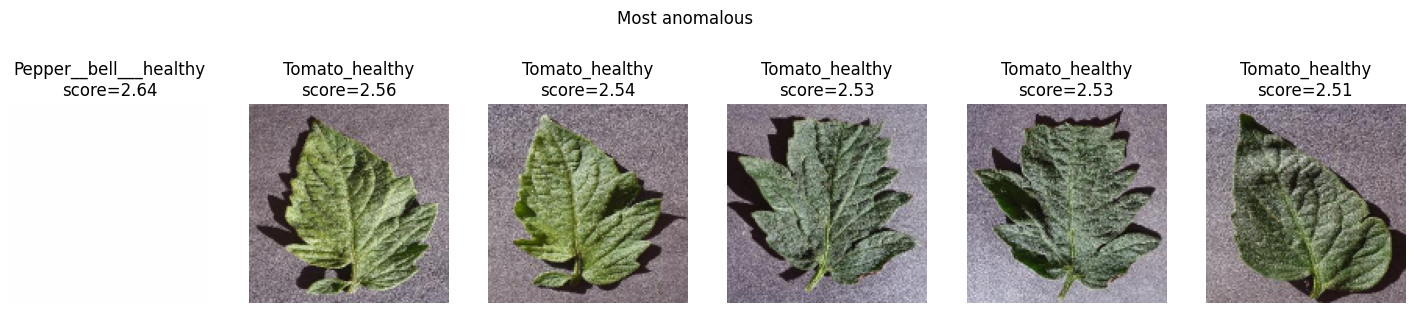

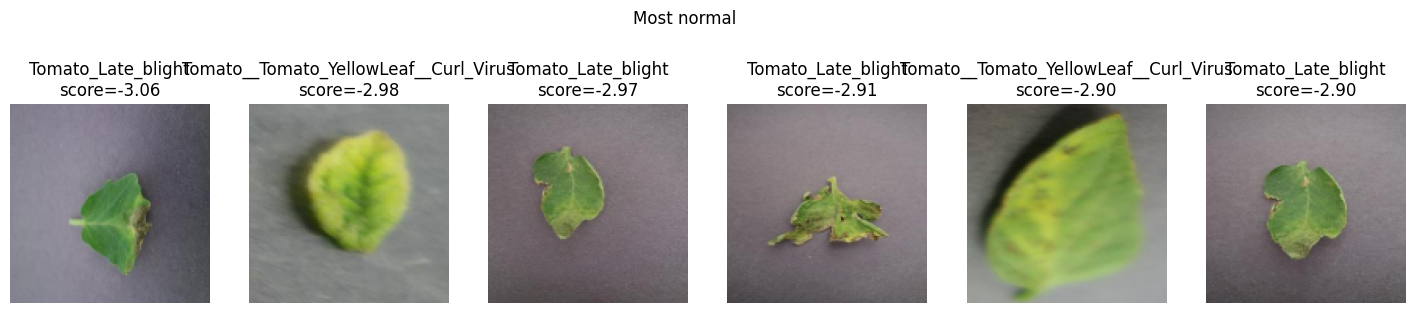

In [45]:
# 9) Visualize examples: most anomalous and most normal
def show_examples(df, k=10, most_anomalous=True):
    if most_anomalous:
        sel = df.sort_values("score_z", ascending=False).head(k)
        title = "Most anomalous"
    else:
        sel = df.sort_values("score_z", ascending=True).head(k)
        title = "Most normal"
    imgs = []
    for p in sel["path"].values:
        img = plt.imread(p)
        img = tf.image.resize(img, [img_height, img_width]).numpy()
        imgs.append(img)
    n = len(imgs)
    plt.figure(figsize=(3*n,4))
    for i, img in enumerate(imgs):
        plt.subplot(1,n,i+1)
        plt.imshow(img.astype(np.uint8))
        lbl = sel["label_name"].iloc[i]
        score = sel["score_z"].iloc[i]
        plt.title(f"{lbl}\nscore={score:.2f}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_examples(df, k=top_k_examples, most_anomalous=True)
show_examples(df, k=top_k_examples, most_anomalous=False)

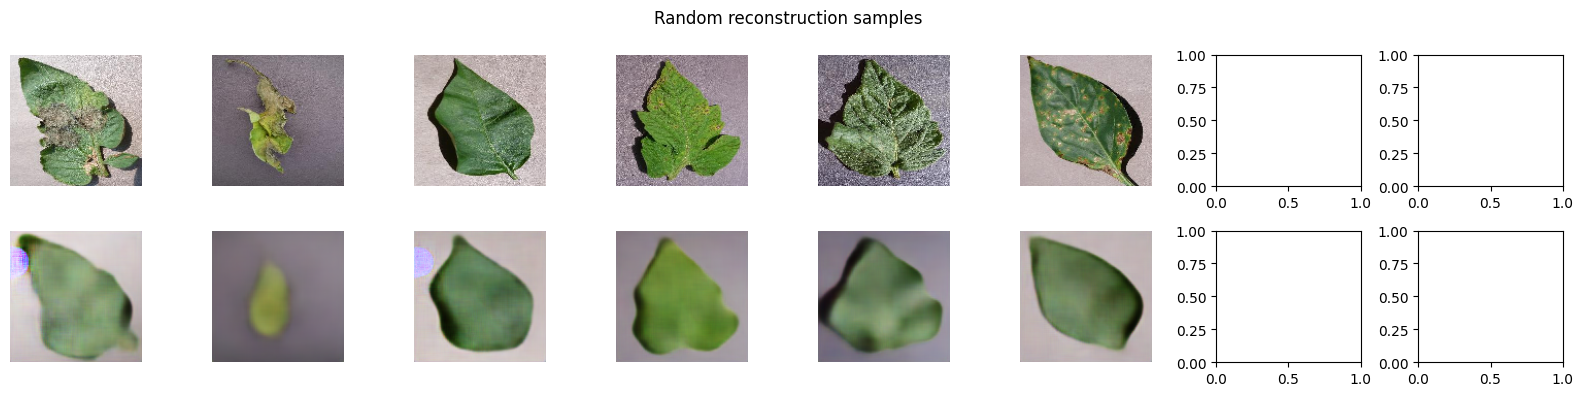

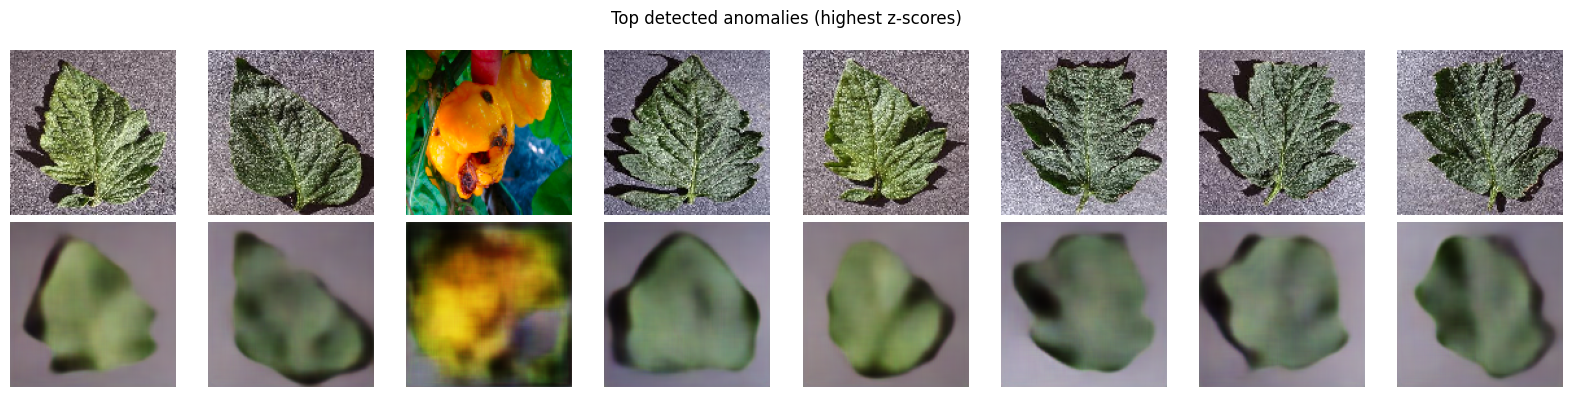

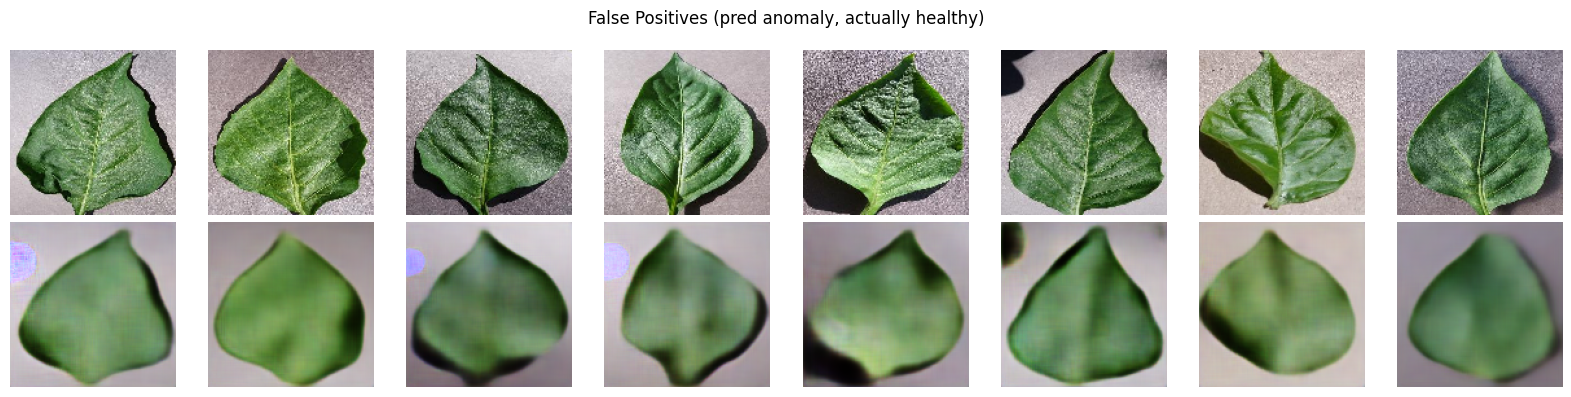

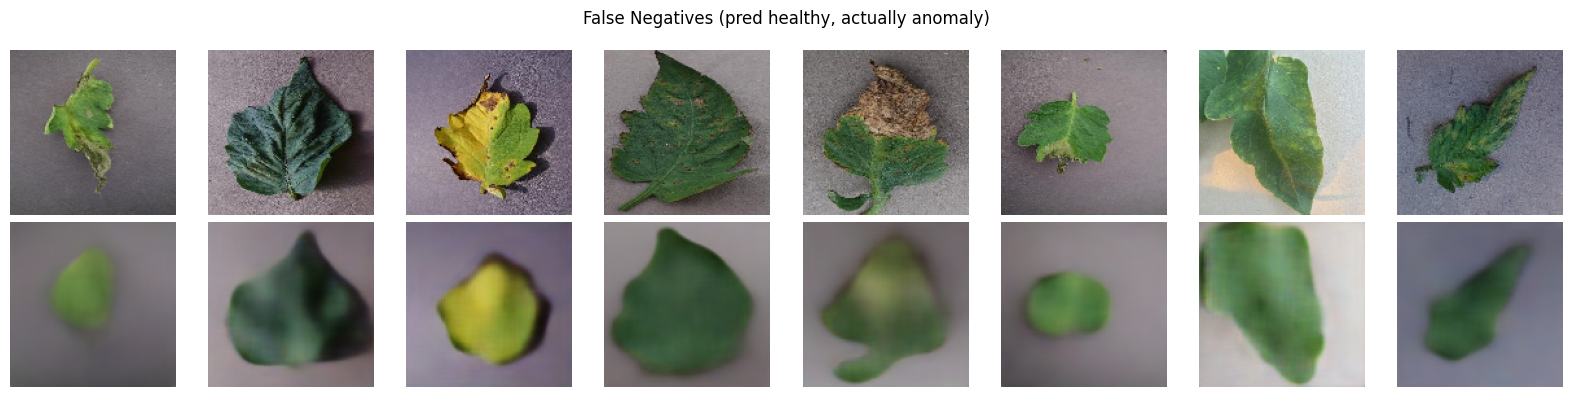

✅ Visualization complete.


In [48]:
# ----------------- Visualization: reconstruction & anomaly inspection -----------------
import matplotlib.pyplot as plt

# Utility: show N examples of images with optional reconstructions
def show_examples(df_subset, title, n=8):
    subset = df_subset.sample(min(n, len(df_subset)), random_state=42)
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = row["path"]
        img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
        img = tf.keras.utils.img_to_array(img) / 255.0
        axes[0, i].imshow(img)
        axes[0, i].axis("off")

        # reconstruction
        z_mean, z_logvar = encoder(tf.expand_dims(img, 0), training=False)
        x_recon = decoder(z_mean, training=False)[0]
        axes[1, i].imshow(x_recon)
        axes[1, i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ---- Reconstruction samples ----
show_examples(df.sample(6), "Random reconstruction samples")

# ---- Top anomalies (highest z-score) ----
top_anoms = df.sort_values("score_z", ascending=False).head(8)
show_examples(top_anoms, "Top detected anomalies (highest z-scores)")

# ---- If labels exist, inspect mistakes ----
if "is_anomaly_label" in df.columns and df["is_anomaly_label"].notna().any():
    # False positives (pred=1, true=0)
    fp = df[(df["pred_is_anomaly_auc"] == 1) & (df["is_anomaly_label"] == 0)]
    if not fp.empty:
        show_examples(fp, "False Positives (pred anomaly, actually healthy)")
    else:
        print("No false positives found.")

    # False negatives (pred=0, true=1)
    fn = df[(df["pred_is_anomaly_auc"] == 0) & (df["is_anomaly_label"] == 1)]
    if not fn.empty:
        show_examples(fn, "False Negatives (pred healthy, actually anomaly)")
    else:
        print("No false negatives found.")

print("✅ Visualization complete.")
# -------------------------------------------------------------------------------


In [50]:
import os
os.makedirs("saved_models", exist_ok=True)

# ✅ Corrected: filename must end with `.weights.h5`
vae.save_weights("saved_models/vae.weights.h5")
print("Saved VAE weights -> saved_models/vae.weights.h5")

# Save encoder and decoder
encoder.save("saved_models/encoder_savedmodel", save_format="tf")
decoder.save("saved_models/decoder_savedmodel", save_format="tf")
print("Saved encoder and decoder as SavedModel folders under saved_models/")

encoder.save_weights("saved_models/encoder.weights.h5")
decoder.save_weights("saved_models/decoder.weights.h5")
print("Saved encoder/decoder weights .weights.h5")


Saved VAE weights -> saved_models/vae.weights.h5


ValueError: The `save_format` argument is deprecated in Keras 3. Please remove this argument and pass a file path with either `.keras` or `.h5` extension.Received: save_format=tf